In [58]:
!pip install hampel

Defaulting to user installation because normal site-packages is not writeable


# 1. Load from raw CSV

In [59]:
from pathlib import Path
import pandas as pd

# # Tìm file CSV CSI mới nhất trong thư mục hiện tại
# csv_files = sorted(Path('.').glob('csi_data_*.csv'), key=lambda p: p.stat().st_mtime)

# if not csv_files:
#     raise FileNotFoundError("Không tìm thấy file dạng csi_data_*.csv trong thư mục hiện tại")

# latest_csv = csv_files[-1]

latest_csv = 'csi_data_20260302_163005_conguoi.csv'
print(f"Đang đọc: {latest_csv}")

df = pd.read_csv(latest_csv)

print("\nKích thước dữ liệu:", df.shape)
print("\nTên cột:")
print(df.columns.tolist())

print("\n5 dòng đầu:")
display(df.head())

Đang đọc: csi_data_20260302_163005_conguoi.csv

Kích thước dữ liệu: (1002, 15)

Tên cột:
['type', 'id', 'mac', 'rssi', 'rate', 'noise_floor', 'fft_gain', 'agc_gain', 'channel', 'local_timestamp', 'sig_len', 'rx_state', 'len', 'first_word', 'data']

5 dòng đầu:


,type,id,mac,rssi,rate,noise_floor,fft_gain,agc_gain,channel,local_timestamp,sig_len,rx_state,len,first_word,data
0,CSI_DATA,573663,1a:00:00:00:00:00,-54,11,-99,26,44,13,-1267634152,47,0,512,0,"[0,0,0,0,0,0,0,0,0,0,-33,20,-33,20,-29,16,-24,..."
1,CSI_DATA,573666,1a:00:00:00:00:00,-55,11,-99,26,44,13,-1267601151,47,0,512,0,"[0,0,0,0,0,0,0,0,0,0,-17,-35,-17,-35,-9,-32,-1..."
2,CSI_DATA,573670,1a:00:00:00:00:00,-55,11,-99,26,44,13,-1267555987,47,0,512,0,"[0,0,0,0,0,0,0,0,0,0,-38,12,-38,12,-32,7,-25,2..."
3,CSI_DATA,573672,1a:00:00:00:00:00,-54,11,-99,26,44,13,-1267535152,47,0,512,0,"[0,0,0,0,0,0,0,0,0,0,11,-34,11,-34,10,-31,10,-..."
4,CSI_DATA,573674,1a:00:00:00:00:00,-54,11,-99,26,44,13,-1267513152,47,0,512,0,"[0,0,0,0,0,0,0,0,0,0,39,-6,39,-6,34,-2,28,2,16..."


# 2. Calculate Amplitude & phase

In [60]:
import json
import numpy as np
import pandas as pd

# Parse chuỗi JSON trong cột `data` -> mảng số
def parse_csi_data(value):
    if pd.isna(value):
        return np.array([], dtype=np.float64)
    if isinstance(value, list):
        return np.asarray(value, dtype=np.float64)
    try:
        return np.asarray(json.loads(value), dtype=np.float64)
    except Exception:
        return np.array([], dtype=np.float64)

# Dữ liệu CSI format C5/C6: [imag0, real0, imag1, real1, ...]
def compute_amplitude_phase(csi_raw):
    if csi_raw.size < 2:
        return np.array([], dtype=np.float64), np.array([], dtype=np.float64)

    imag = csi_raw[0::2]
    real = csi_raw[1::2]

    length = min(len(real), len(imag))
    real = real[:length]
    imag = imag[:length]

    amplitude = np.sqrt(real**2 + imag**2)
    phase = np.arctan2(imag, real)
    return amplitude, phase

# Tính cho toàn bộ dataframe
df_calc = df.copy()
df_calc["csi_raw"] = df_calc["data"].apply(parse_csi_data)
df_calc[["amplitude", "phase"]] = df_calc["csi_raw"].apply(
    lambda raw: pd.Series(compute_amplitude_phase(raw))
)

# Feature thống kê nhanh theo từng packet
df_calc["subcarrier_count"] = df_calc["amplitude"].apply(len)
df_calc["amp_mean"] = df_calc["amplitude"].apply(lambda x: float(np.mean(x)) if len(x) else np.nan)
df_calc["amp_std"] = df_calc["amplitude"].apply(lambda x: float(np.std(x)) if len(x) else np.nan)
df_calc["phase_mean"] = df_calc["phase"].apply(lambda x: float(np.mean(x)) if len(x) else np.nan)
df_calc["phase_std"] = df_calc["phase"].apply(lambda x: float(np.std(x)) if len(x) else np.nan)

print("Hoàn tất tính amplitude & phase")
print("Số packet:", len(df_calc))
print("Subcarrier/packet (min/max):", int(df_calc["subcarrier_count"].min()), "/", int(df_calc["subcarrier_count"].max()))

display(
    df_calc[["rssi", "len", "subcarrier_count", "amp_mean", "amp_std", "phase_mean", "phase_std"]].head()
 )

# Xem chi tiết packet đầu tiên
first_idx = df_calc["subcarrier_count"].gt(0).idxmax()
print(f"\nPacket mẫu index: {first_idx}")
print("5 amplitude đầu:", df_calc.loc[first_idx, "amplitude"][:5])
print("5 phase đầu:", df_calc.loc[first_idx, "phase"][:5])

Hoàn tất tính amplitude & phase
Số packet: 1002
Subcarrier/packet (min/max): 256 / 256


,rssi,len,subcarrier_count,amp_mean,amp_std,phase_mean,phase_std
0,-54,512,256,42.573992,17.705327,0.207693,1.102920
1,-55,512,256,40.767097,20.168839,-1.013229,1.377933
2,-55,512,256,42.896015,16.848889,0.460570,1.648327
3,-54,512,256,42.854440,16.978297,0.122436,1.833688
4,-54,512,256,41.432661,19.553877,0.420007,1.675195



Packet mẫu index: 0
5 amplitude đầu: [0. 0. 0. 0. 0.]
5 phase đầu: [0. 0. 0. 0. 0.]


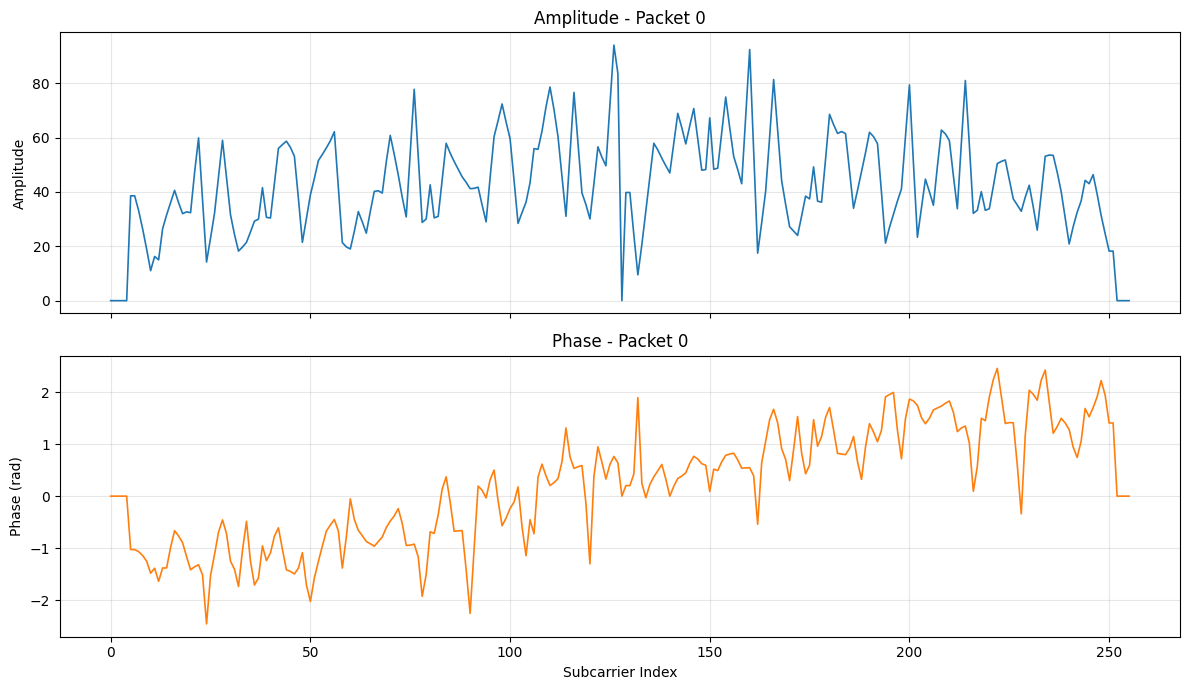

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# Chọn packet đầu tiên có dữ liệu hợp lệ
valid_packets = df_calc[df_calc["subcarrier_count"] > 0]
if valid_packets.empty:
    raise ValueError("Không có packet hợp lệ để plot")

sample_idx = valid_packets.index[0]
amp = np.asarray(df_calc.loc[sample_idx, "amplitude"])
phs = np.asarray(df_calc.loc[sample_idx, "phase"])
subcarrier_idx = np.arange(len(amp))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(subcarrier_idx, amp, color="tab:blue", linewidth=1.2)
axes[0].set_title(f"Amplitude - Packet {sample_idx}")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(subcarrier_idx, phs, color="tab:orange", linewidth=1.2)
axes[1].set_title(f"Phase - Packet {sample_idx}")
axes[1].set_ylabel("Phase (rad)")
axes[1].set_xlabel("Subcarrier Index")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Extract Subcarrier 10 Time Series

In [62]:
import numpy as np
import pandas as pd

print(f"Trích xuất tất cả subcarrier từ tất cả packet...\n")

# Tạo dictionary chứa time series của từng subcarrier
ts_all = {}

# Xác định số subcarrier tối đa
max_subcarrier = int(df_calc["subcarrier_count"].max())

print(f"Số subcarrier: {max_subcarrier}")

# Trích xuất từng subcarrier
for subcarrier_idx in range(max_subcarrier):
    timeseries_data = []
    
    for packet_idx in df_calc.index:
        amp = np.asarray(df_calc.loc[packet_idx, "amplitude"])
        phs = np.asarray(df_calc.loc[packet_idx, "phase"])
        
        if len(amp) <= subcarrier_idx:
            continue
        
        timeseries_data.append({
            "packet_idx": packet_idx,
            # "rssi": df_calc.loc[packet_idx, "rssi"],
            # "fft_gain": df_calc.loc[packet_idx, "fft_gain"],
            # "agc_gain": df_calc.loc[packet_idx, "agc_gain"],
            "amp": amp[subcarrier_idx],
            "phase": phs[subcarrier_idx],
        })
    
    if len(timeseries_data) > 0:
        ts_all[subcarrier_idx] = pd.DataFrame(timeseries_data)

print(f"Trích xuất thành công {len(ts_all)} subcarrier")
print(f"Số packet per subcarrier: min={min(len(ts_all[k]) for k in ts_all)}, max={max(len(ts_all[k]) for k in ts_all)}")

# Set SUBCARRIER_INDEX cho phần visualization sau này
SUBCARRIER_INDEX = 10
if SUBCARRIER_INDEX not in ts_all:
    SUBCARRIER_INDEX = list(ts_all.keys())[0]
    print(f"Subcarrier 10 không có đủ dữ liệu, sử dụng subcarrier {SUBCARRIER_INDEX}")

print(f"\nThống kê gốc Subcarrier {SUBCARRIER_INDEX}:")
ts_sample = ts_all[SUBCARRIER_INDEX]
print(f"  Amplitude: mean={ts_sample['amp'].mean():.3f}, std={ts_sample['amp'].std():.3f}")
print(f"  Phase: mean={ts_sample['phase'].mean():.3f}, std={ts_sample['phase'].std():.3f}")

Trích xuất tất cả subcarrier từ tất cả packet...

Số subcarrier: 256
Trích xuất thành công 256 subcarrier
Số packet per subcarrier: min=1002, max=1002

Thống kê gốc Subcarrier 10:
  Amplitude: mean=10.993, std=4.072
  Phase: mean=-0.017, std=1.885


In [63]:
import numpy as np
import pandas as pd
from hampel import hampel

# Tham số Hampel
K_WINDOW = 30 # 200 => 30
N_SIGMA = 2.0

print(f"Áp dụng Hampel filter (k={K_WINDOW}, nσ={N_SIGMA}) cho tất cả {len(ts_all)} subcarrier...\n")

# Áp dụng Hampel cho mỗi subcarrier
for sub_idx in ts_all.keys():
    ts_df = ts_all[sub_idx]
    
    # Hampel filter
    amp_hampel_res = hampel(ts_df['amp'].values, window_size=K_WINDOW, n_sigma=N_SIGMA)
    amp_hampel = amp_hampel_res.filtered_data
    amp_hampel_outliers = np.zeros(len(ts_df), dtype=bool)
    amp_hampel_outliers[amp_hampel_res.outlier_indices] = True
    
    phs_hampel_res = hampel(ts_df['phase'].values, window_size=K_WINDOW, n_sigma=N_SIGMA)
    phs_hampel = phs_hampel_res.filtered_data
    phs_hampel_outliers = np.zeros(len(ts_df), dtype=bool)
    phs_hampel_outliers[phs_hampel_res.outlier_indices] = True
    
    # Lưu vào dict
    ts_all[sub_idx]["amp_hampel"] = amp_hampel
    ts_all[sub_idx]["amp_hampel_outliers"] = amp_hampel_outliers
    ts_all[sub_idx]["phase_hampel"] = phs_hampel
    ts_all[sub_idx]["phase_hampel_outliers"] = phs_hampel_outliers

print(f"Hoàn tất Hampel filter cho tất cả subcarrier")

# Hiển thị thống kê cho subcarrier 10
ts_sample = ts_all[SUBCARRIER_INDEX]
print(f"\nThống kê sau Hampel - Subcarrier {SUBCARRIER_INDEX}:")
print(f"  Amplitude outliers: {np.sum(ts_sample['amp_hampel_outliers'])} ({100*np.sum(ts_sample['amp_hampel_outliers'])/len(ts_sample):.2f}%)")
print(f"  Phase outliers: {np.sum(ts_sample['phase_hampel_outliers'])} ({100*np.sum(ts_sample['phase_hampel_outliers'])/len(ts_sample):.2f}%)")

Áp dụng Hampel filter (k=30, nσ=2.0) cho tất cả 256 subcarrier...

Hoàn tất Hampel filter cho tất cả subcarrier

Thống kê sau Hampel - Subcarrier 10:
  Amplitude outliers: 92 (9.18%)
  Phase outliers: 5 (0.50%)


# 4. Savitzky-Golay Filter (Smoothing)

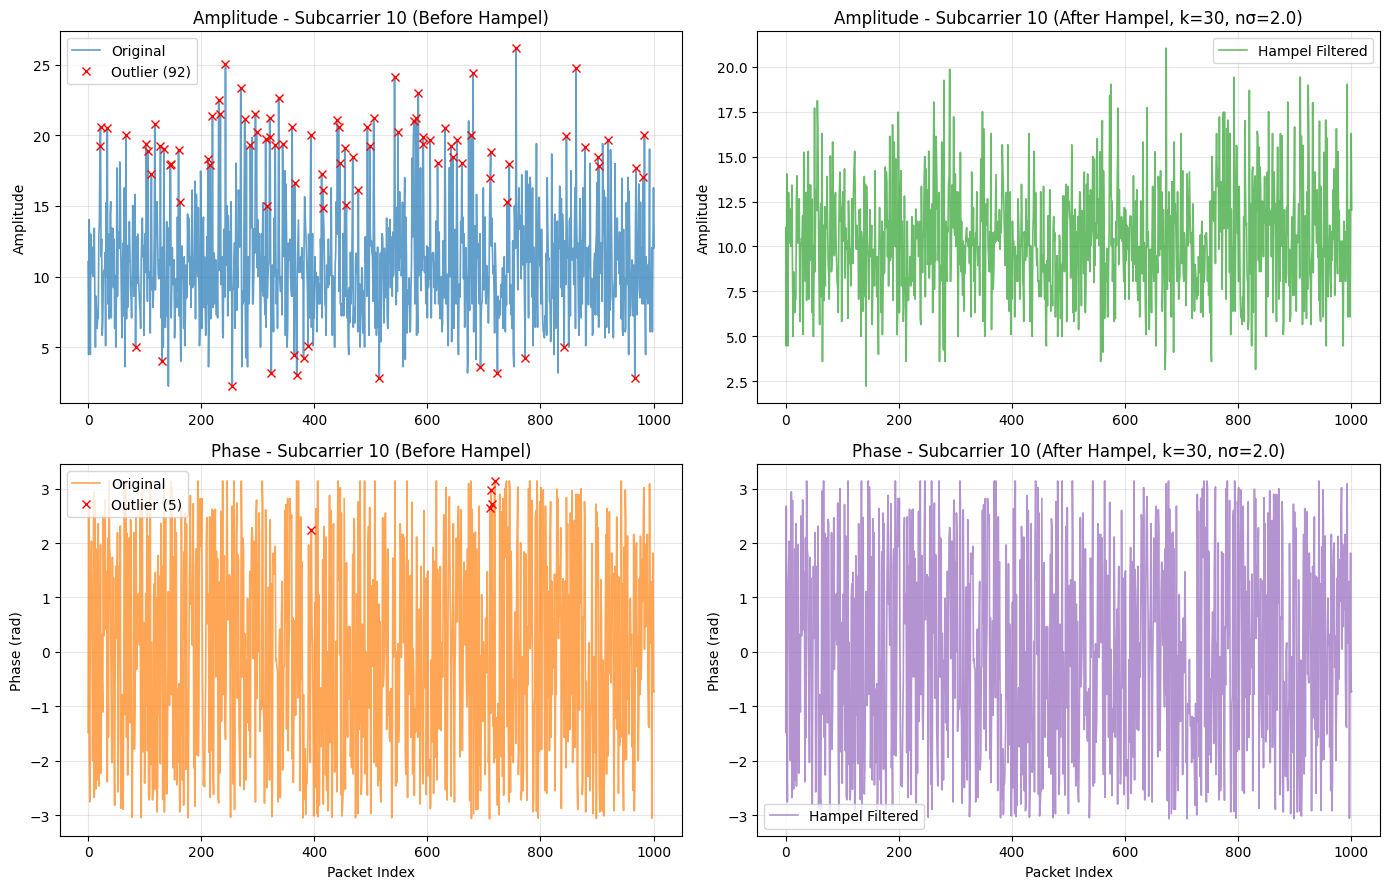

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Chỉ plot subcarrier 10
ts_df = ts_all[SUBCARRIER_INDEX]
packet_idx = np.arange(len(ts_df))

# Lấy ra index của outlier
amp_outlier_idx = np.where(ts_df['amp_hampel_outliers'])[0]
phs_outlier_idx = np.where(ts_df['phase_hampel_outliers'])[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Plot 1: Amplitude - Trước Hampel
axes[0, 0].plot(packet_idx, ts_df['amp'], "", color="tab:blue", 
                linewidth=1.2, markersize=4, alpha=0.7, label="Original")
if len(amp_outlier_idx) > 0:
    axes[0, 0].plot(amp_outlier_idx, ts_df['amp'].iloc[amp_outlier_idx], "rx", 
                    markersize=6, linewidth=2, label=f"Outlier ({len(amp_outlier_idx)})")
axes[0, 0].set_title(f"Amplitude - Subcarrier {SUBCARRIER_INDEX} (Before Hampel)")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Plot 2: Amplitude - Sau Hampel
axes[0, 1].plot(packet_idx, ts_df['amp_hampel'], "", color="tab:green", 
                linewidth=1.2, markersize=4, alpha=0.7, label="Hampel Filtered")
axes[0, 1].set_title(f"Amplitude - Subcarrier {SUBCARRIER_INDEX} (After Hampel, k={K_WINDOW}, nσ={N_SIGMA})")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# Plot 3: Phase - Trước Hampel
axes[1, 0].plot(packet_idx, ts_df['phase'], "", color="tab:orange", 
                linewidth=1.2, markersize=4, alpha=0.7, label="Original")
if len(phs_outlier_idx) > 0:
    axes[1, 0].plot(phs_outlier_idx, ts_df['phase'].iloc[phs_outlier_idx], "rx", 
                    markersize=6, linewidth=2, label=f"Outlier ({len(phs_outlier_idx)})")
axes[1, 0].set_title(f"Phase - Subcarrier {SUBCARRIER_INDEX} (Before Hampel)")
axes[1, 0].set_ylabel("Phase (rad)")
axes[1, 0].set_xlabel("Packet Index")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# Plot 4: Phase - Sau Hampel
axes[1, 1].plot(packet_idx, ts_df['phase_hampel'], "", color="tab:purple", 
                linewidth=1.2, markersize=4, alpha=0.7, label="Hampel Filtered")
axes[1, 1].set_title(f"Phase - Subcarrier {SUBCARRIER_INDEX} (After Hampel, k={K_WINDOW}, nσ={N_SIGMA})")
axes[1, 1].set_ylabel("Phase (rad)")
axes[1, 1].set_xlabel("Packet Index")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [65]:
from scipy.signal import savgol_filter
import numpy as np

# Tham số Savitzky-Golay
POLYORDER = 3      # Bậc đa thức
WINDOW_LENGTH = 51 # Kích thước cửa sổ

print(f"Áp dụng Savitzky-Golay Filter (p={POLYORDER}, l={WINDOW_LENGTH}) cho tất cả subcarriers...\n")

# Áp dụng SG filter cho tất cả subcarriers
for sub_idx in ts_all.keys():
    ts_df = ts_all[sub_idx]
    
    amp_len = len(ts_df)
    window_len = min(WINDOW_LENGTH, amp_len if amp_len % 2 == 1 else amp_len - 1)
    
    # Áp dụng SG filter từ amplitude & phase đã qua Hampel
    if window_len >= POLYORDER + 1:
        amp_sg = savgol_filter(ts_df['amp_hampel'].values, window_length=window_len, polyorder=POLYORDER)
    else:
        amp_sg = ts_df['amp_hampel'].values
    
    if window_len >= POLYORDER + 1:
        phs_sg = savgol_filter(ts_df['phase_hampel'].values, window_length=window_len, polyorder=POLYORDER)
    else:
        phs_sg = ts_df['phase_hampel'].values
    
    # Lưu vào dataframe
    ts_all[sub_idx]["amp_sg"] = amp_sg
    ts_all[sub_idx]["phase_sg"] = phs_sg

print(f"Hoàn tất SG filter cho tất cả {len(ts_all)} subcarriers")
print(f"Thông số: polyorder={POLYORDER}, window_length={WINDOW_LENGTH}\n")

# Hiển thị thống kê cho subcarrier tham chiếu
ts_sample = ts_all[SUBCARRIER_INDEX]
print(f"Thống kê cho Subcarrier {SUBCARRIER_INDEX} sau Savitzky-Golay:")
print(f"  Amplitude: mean={np.mean(ts_sample['amp_sg']):.3f}, std={np.std(ts_sample['amp_sg']):.3f}")
print(f"  Phase: mean={np.mean(ts_sample['phase_sg']):.3f}, std={np.std(ts_sample['phase_sg']):.3f}")

# So sánh MSE giữa Hampel và SG
amp_mse = np.mean((ts_sample['amp_hampel'].values - ts_sample['amp_sg'].values)**2)
phs_mse = np.mean((ts_sample['phase_hampel'].values - ts_sample['phase_sg'].values)**2)

print(f"\nMSE (Hampel → SG) cho Subcarrier {SUBCARRIER_INDEX}:")
print(f"  Amplitude: {amp_mse:.6f}")
print(f"  Phase: {phs_mse:.6f}")

Áp dụng Savitzky-Golay Filter (p=3, l=51) cho tất cả subcarriers...

Hoàn tất SG filter cho tất cả 256 subcarriers
Thông số: polyorder=3, window_length=51

Thống kê cho Subcarrier 10 sau Savitzky-Golay:
  Amplitude: mean=10.366, std=0.865
  Phase: mean=-0.036, std=0.447

MSE (Hampel → SG) cho Subcarrier 10:
  Amplitude: 8.593975
  Phase: 3.322988


# 5. Visualization - Hampel vs Savitzky-Golay vs Final

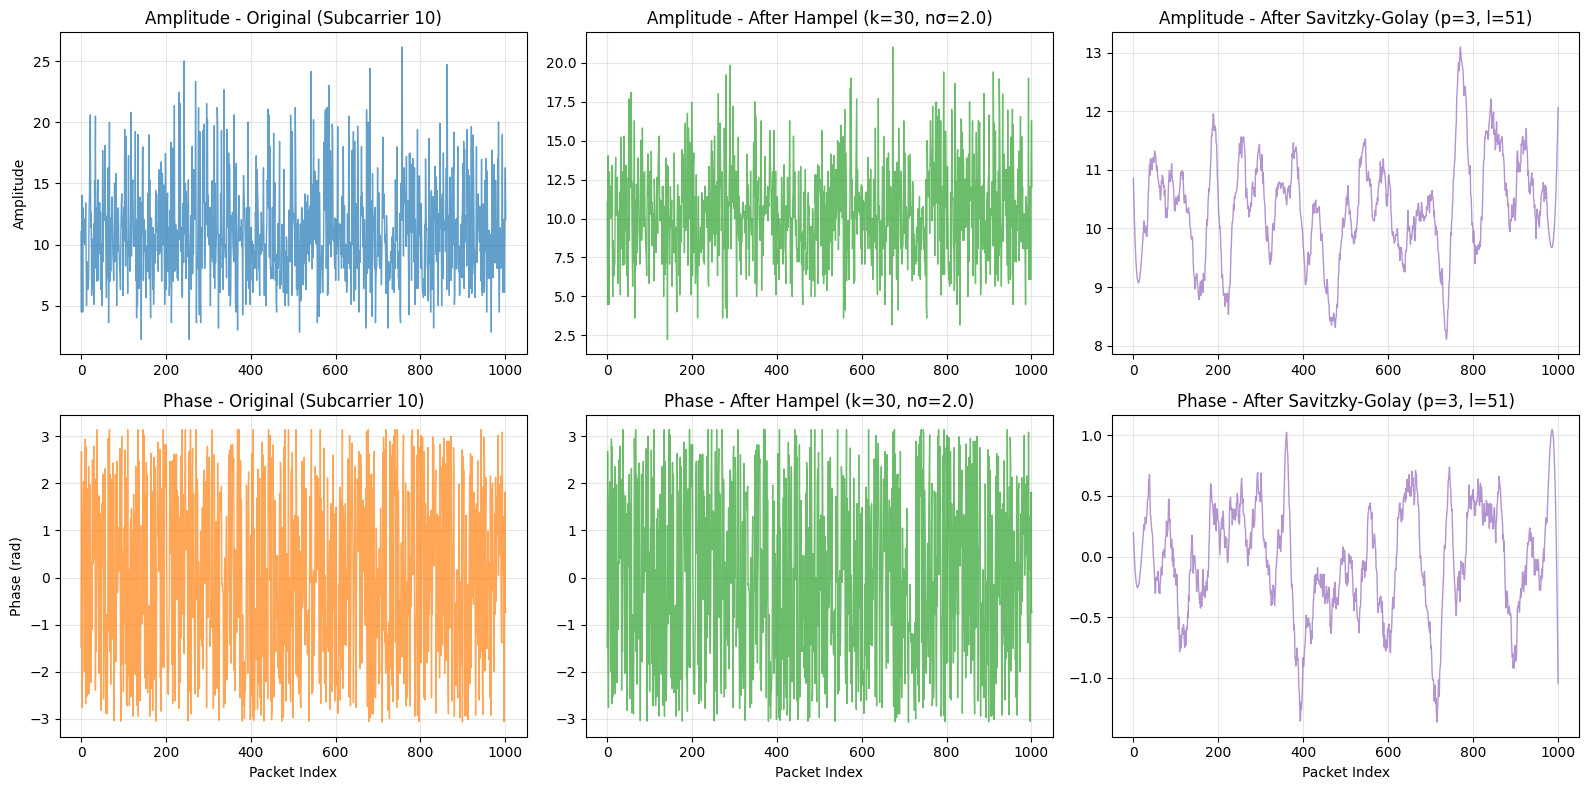

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Lấy dữ liệu từ dict cho subcarrier 10
ts_df = ts_all[SUBCARRIER_INDEX]

if ts_df.empty:
    raise ValueError("Time series dataframe trống, không thể vẽ")

packet_idx = np.arange(len(ts_df))

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Row 1: Amplitude
axes[0, 0].plot(packet_idx, ts_df['amp'], "", color="tab:blue", linewidth=1, markersize=3, alpha=0.7)
axes[0, 0].set_title(f"Amplitude - Original (Subcarrier {SUBCARRIER_INDEX})")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(packet_idx, ts_df['amp_hampel'], "", color="tab:green", linewidth=1, markersize=3, alpha=0.7)
axes[0, 1].set_title(f"Amplitude - After Hampel (k={K_WINDOW}, nσ={N_SIGMA})")
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(packet_idx, ts_df['amp_sg'], "", color="tab:purple", linewidth=1, markersize=3, alpha=0.7)
axes[0, 2].set_title(f"Amplitude - After Savitzky-Golay (p={POLYORDER}, l={WINDOW_LENGTH})")
axes[0, 2].grid(True, alpha=0.3)

# Row 2: Phase
axes[1, 0].plot(packet_idx, ts_df['phase'], "", color="tab:orange", linewidth=1, markersize=3, alpha=0.7)
axes[1, 0].set_title(f"Phase - Original (Subcarrier {SUBCARRIER_INDEX})")
axes[1, 0].set_ylabel("Phase (rad)")
axes[1, 0].set_xlabel("Packet Index")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(packet_idx, ts_df['phase_hampel'], "", color="tab:green", linewidth=1, markersize=3, alpha=0.7)
axes[1, 1].set_title(f"Phase - After Hampel (k={K_WINDOW}, nσ={N_SIGMA})")
axes[1, 1].set_xlabel("Packet Index")
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(packet_idx, ts_df['phase_sg'], "", color="tab:purple", linewidth=1, markersize=3, alpha=0.7)
axes[1, 2].set_title(f"Phase - After Savitzky-Golay (p={POLYORDER}, l={WINDOW_LENGTH})")
axes[1, 2].set_xlabel("Packet Index")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Elliptic Bandpass Filter (0.1–0.4 Hz)

In [67]:
import numpy as np
from scipy.signal import ellip, sosfiltfilt

# Giả sử tốc độ thu ~100 packet/s => fs = 100 Hz
FS = 100.0
LOWCUT = 0.15
HIGHCUT = 0.45
ORDER = 2 # 4 => 2
RP = 0.15    # passband ripple (dB)
RS = 30     # stopband attenuation (dB)

nyquist = FS / 2
if HIGHCUT >= nyquist:
    raise ValueError(f"HIGHCUT={HIGHCUT} phải nhỏ hơn Nyquist={nyquist}")

# Thiết kế Elliptic bandpass dưới dạng SOS để ổn định số học
sos = ellip(
    N=ORDER,
    rp=RP,
    rs=RS,
    Wn=[LOWCUT / nyquist, HIGHCUT / nyquist],
    btype='bandpass',
    output='sos'
)

print(f"Áp dụng Elliptic Bandpass Filter ({LOWCUT}-{HIGHCUT} Hz) cho tất cả subcarriers...\n")

# Áp dụng cho tất cả subcarriers
for sub_idx in ts_all.keys():
    ts_df = ts_all[sub_idx]
    
    # Lấy input từ bước SG nếu có, không thì từ Hampel
    amp_in = ts_df['amp_sg'].values if 'amp_sg' in ts_df.columns else ts_df['amp_hampel'].values
    phs_in = ts_df['phase_sg'].values if 'phase_sg' in ts_df.columns else ts_df['phase_hampel'].values
    
    # Áp dụng filtfilt (zerphase) để không lệch pha
    amp_ellip = sosfiltfilt(sos, amp_in)
    phs_ellip = sosfiltfilt(sos, phs_in)
    
    # Lưu vào dataframe
    ts_all[sub_idx]['amp_ellip'] = amp_ellip
    ts_all[sub_idx]['phase_ellip'] = phs_ellip

print(f"Hoàn tất Elliptic filter cho tất cả {len(ts_all)} subcarriers")
print(f"Thông số: ordnung={ORDER}, rp={RP}dB, rs={RS}dB, tợc độ={LOWCUT}-{HIGHCUT} Hz\n")

# Hiển thị thống kê cho tham chiếu subcarrier
ts_sample = ts_all[SUBCARRIER_INDEX]
print(f"Thống kê sau Elliptic Bandpass cho Subcarrier {SUBCARRIER_INDEX}:")
print(f"  Amplitude: mean={np.mean(ts_sample['amp_ellip']):.3f}, std={np.std(ts_sample['amp_ellip']):.3f}")
print(f"  Phase: mean={np.mean(ts_sample['phase_ellip']):.3f}, std={np.std(ts_sample['phase_ellip']):.3f}")

Áp dụng Elliptic Bandpass Filter (0.15-0.45 Hz) cho tất cả subcarriers...

Hoàn tất Elliptic filter cho tất cả 256 subcarriers
Thông số: ordnung=2, rp=0.15dB, rs=30dB, tợc độ=0.15-0.45 Hz

Thống kê sau Elliptic Bandpass cho Subcarrier 10:
  Amplitude: mean=-0.072, std=0.430
  Phase: mean=-0.021, std=0.228


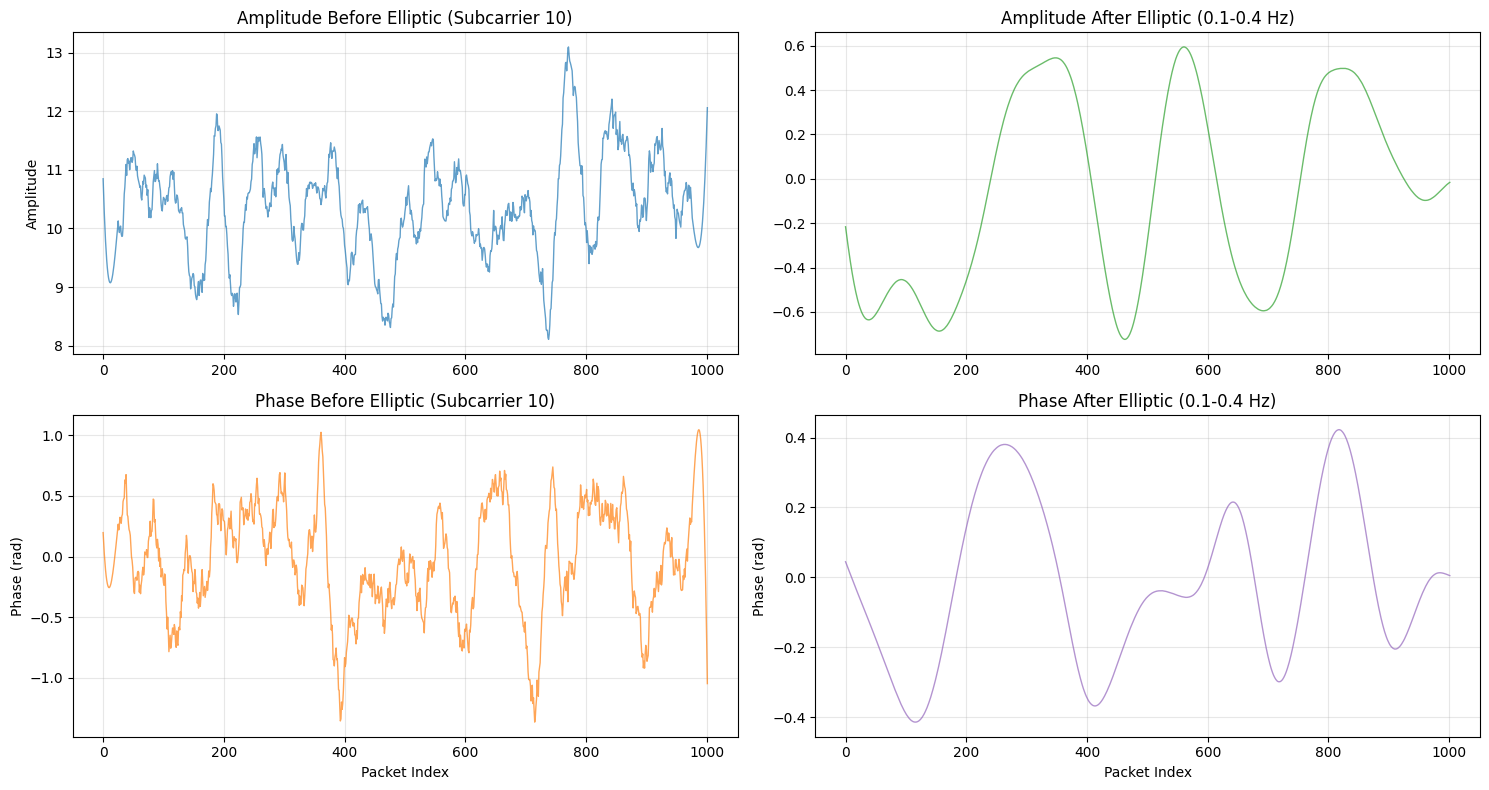

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# Hiển thị Elliptic filter effect trên subcarrier 10
ts_df = ts_all[SUBCARRIER_INDEX]

packet_idx = np.arange(len(ts_df))

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Amplitude trước Elliptic (từ SG nếu có)
amp_before = ts_df['amp_sg'].values if 'amp_sg' in ts_df.columns else ts_df['amp_hampel'].values

axes[0, 0].plot(packet_idx, amp_before, '', color='tab:blue', linewidth=1, markersize=3, alpha=0.7)
axes[0, 0].set_title(f'Amplitude Before Elliptic (Subcarrier {SUBCARRIER_INDEX})')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(packet_idx, ts_df['amp_ellip'], '', color='tab:green', linewidth=1, markersize=3, alpha=0.7)
axes[0, 1].set_title(f'Amplitude After Elliptic (0.1-0.4 Hz)')
axes[0, 1].grid(True, alpha=0.3)

# Phase trước Elliptic
phs_before = ts_df['phase_sg'].values if 'phase_sg' in ts_df.columns else ts_df['phase_hampel'].values

axes[1, 0].plot(packet_idx, phs_before, '', color='tab:orange', linewidth=1, markersize=3, alpha=0.7)
axes[1, 0].set_title(f'Phase Before Elliptic (Subcarrier {SUBCARRIER_INDEX})')
axes[1, 0].set_ylabel('Phase (rad)')
axes[1, 0].set_xlabel('Packet Index')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(packet_idx, ts_df['phase_ellip'], '', color='tab:purple', linewidth=1, markersize=3, alpha=0.7)
axes[1, 1].set_title(f'Phase After Elliptic (0.1-0.4 Hz)')
axes[1, 1].set_ylabel('Phase (rad)')
axes[1, 1].set_xlabel('Packet Index')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_369251/1208198014.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


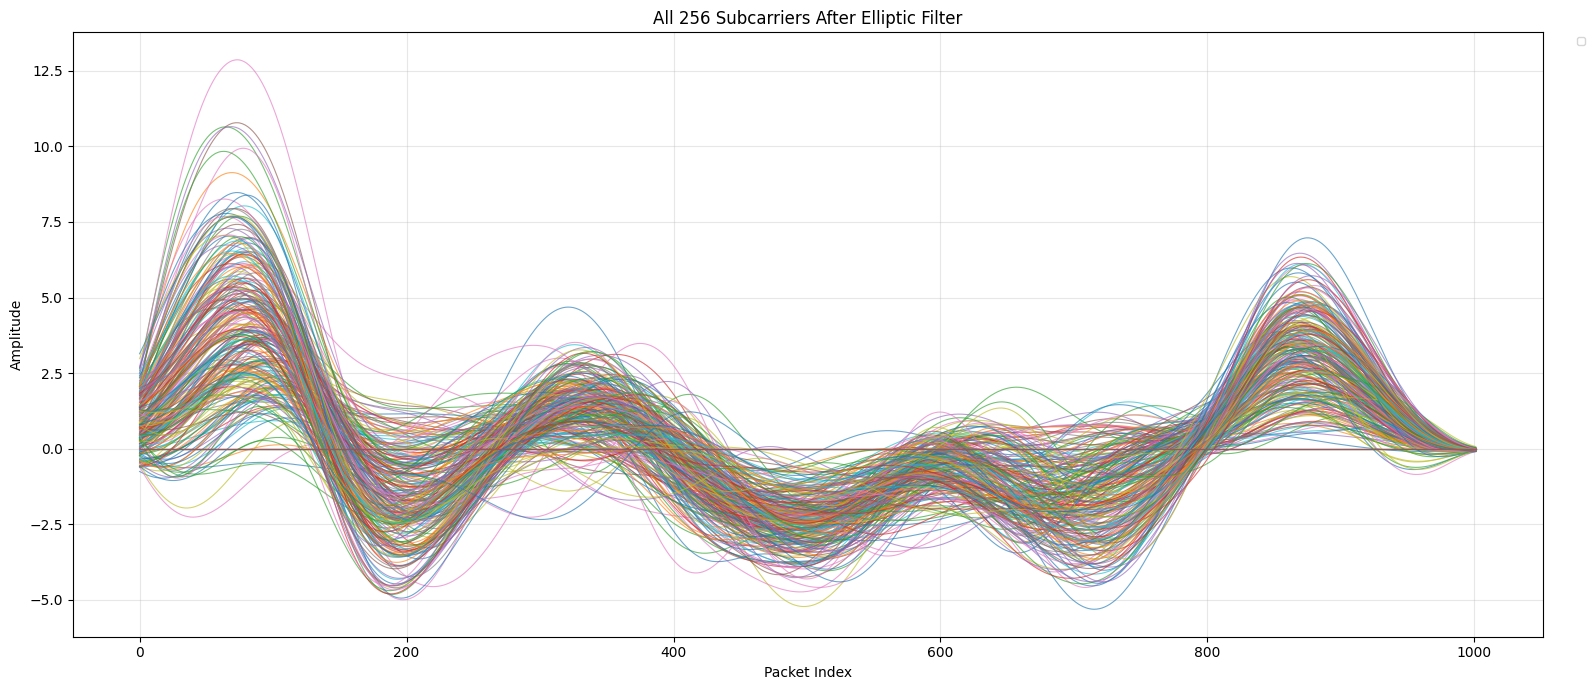

Plotted 256 subcarriers after elliptic filter in single plot


In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Plot tất cả subcarriers sau Elliptic filter trên cùng một biểu đồ
num_subcarriers = len(ts_all)

if num_subcarriers == 0:
    raise ValueError("ts_all rỗng, không có subcarrier để vẽ")

fig, ax = plt.subplots(figsize=(16, 7))

for sub_idx in sorted(ts_all.keys()):
    ts_df = ts_all[sub_idx]
    if 'amp_ellip' not in ts_df.columns:
        continue
    ax.plot(
        np.arange(len(ts_df)),
        ts_df['amp_ellip'].values,
        linewidth=0.8,
        alpha=0.65,
        # label=f'SC{sub_idx}'
    )

ax.set_xlabel('Packet Index')
ax.set_ylabel('Amplitude')
ax.set_title(f'All {num_subcarriers} Subcarriers After Elliptic Filter')
ax.grid(True, alpha=0.3)

# Legend đặt ngoài biểu đồ để tránh che dữ liệu
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    ncol=1,
    fontsize=7,
    frameon=True
)

plt.tight_layout()
plt.show()

print(f'Plotted {num_subcarriers} subcarriers after elliptic filter in single plot')

# 7. PCA Dimensionality Reduction - Top 5 Components

Ma trận amplitude: (1002, 256)
Ma trận phase: (1002, 256)

PCA Amplitude:
  Input shape: (1002, 256)
  Output shape: (1002, 5)
  Explained variance ratio: [0.83174775 0.07031886 0.06074397 0.01501947 0.00687022]
  Total variance explained: 98.47%

PCA Phase:
  Input shape: (1002, 256)
  Output shape: (1002, 5)
  Explained variance ratio: [0.72351224 0.1294992  0.05252764 0.02664153 0.02029897]
  Total variance explained: 95.25%


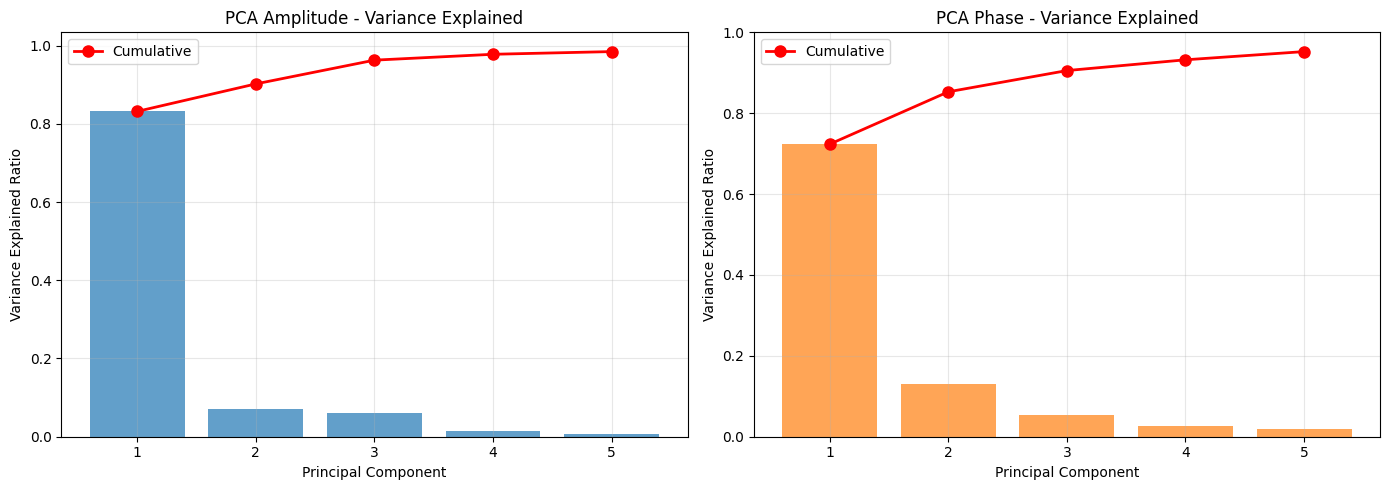


PCA hoàn tất! Giảm từ 256 subcarriers xuống 5 principal components


In [70]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Chuẩn bị ma trận dữ liệu: mỗi hàng là 1 packet, mỗi cột là 1 subcarrier
num_packets = max([len(ts_all[k]) for k in ts_all.keys()])
num_subcarriers = len(ts_all)

# Khởi tạo ma trận amplitude và phase
amp_matrix = np.zeros((num_packets, num_subcarriers))
phs_matrix = np.zeros((num_packets, num_subcarriers))

# Điền dữ liệu từ ts_all (sau khi đã qua filters: Hampel, SG, Elliptic)
for sub_idx in sorted(ts_all.keys()):
    ts_df = ts_all[sub_idx]
    n_samples = len(ts_df)
    amp_matrix[:n_samples, sub_idx] = ts_df['amp_ellip'].values
    phs_matrix[:n_samples, sub_idx] = ts_df['phase_ellip'].values

print(f"Ma trận amplitude: {amp_matrix.shape}")
print(f"Ma trận phase: {phs_matrix.shape}")

# Áp dụng PCA cho amplitude (giảm từ 256 xuống 5 thành phần chính)
N_COMPONENTS = 5
pca_amp = PCA(n_components=N_COMPONENTS)
amp_pca = pca_amp.fit_transform(amp_matrix)

print(f"\nPCA Amplitude:")
print(f"  Input shape: {amp_matrix.shape}")
print(f"  Output shape: {amp_pca.shape}")
print(f"  Explained variance ratio: {pca_amp.explained_variance_ratio_}")
print(f"  Total variance explained: {np.sum(pca_amp.explained_variance_ratio_)*100:.2f}%")

# Áp dụng PCA cho phase
pca_phs = PCA(n_components=N_COMPONENTS)
phs_pca = pca_phs.fit_transform(phs_matrix)

print(f"\nPCA Phase:")
print(f"  Input shape: {phs_matrix.shape}")
print(f"  Output shape: {phs_pca.shape}")
print(f"  Explained variance ratio: {pca_phs.explained_variance_ratio_}")
print(f"  Total variance explained: {np.sum(pca_phs.explained_variance_ratio_)*100:.2f}%")

# Vẽ biểu đồ variance explained
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amplitude variance
axes[0].bar(range(1, N_COMPONENTS+1), pca_amp.explained_variance_ratio_, alpha=0.7, color='tab:blue')
axes[0].plot(range(1, N_COMPONENTS+1), np.cumsum(pca_amp.explained_variance_ratio_), 
             'ro-', linewidth=2, markersize=8, label='Cumulative')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('PCA Amplitude - Variance Explained')
axes[0].set_xticks(range(1, N_COMPONENTS+1))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Phase variance
axes[1].bar(range(1, N_COMPONENTS+1), pca_phs.explained_variance_ratio_, alpha=0.7, color='tab:orange')
axes[1].plot(range(1, N_COMPONENTS+1), np.cumsum(pca_phs.explained_variance_ratio_), 
             'ro-', linewidth=2, markersize=8, label='Cumulative')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance Explained Ratio')
axes[1].set_title('PCA Phase - Variance Explained')
axes[1].set_xticks(range(1, N_COMPONENTS+1))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPCA hoàn tất! Giảm từ {num_subcarriers} subcarriers xuống {N_COMPONENTS} principal components")

# 8. Visualization - Top 5 Principal Components

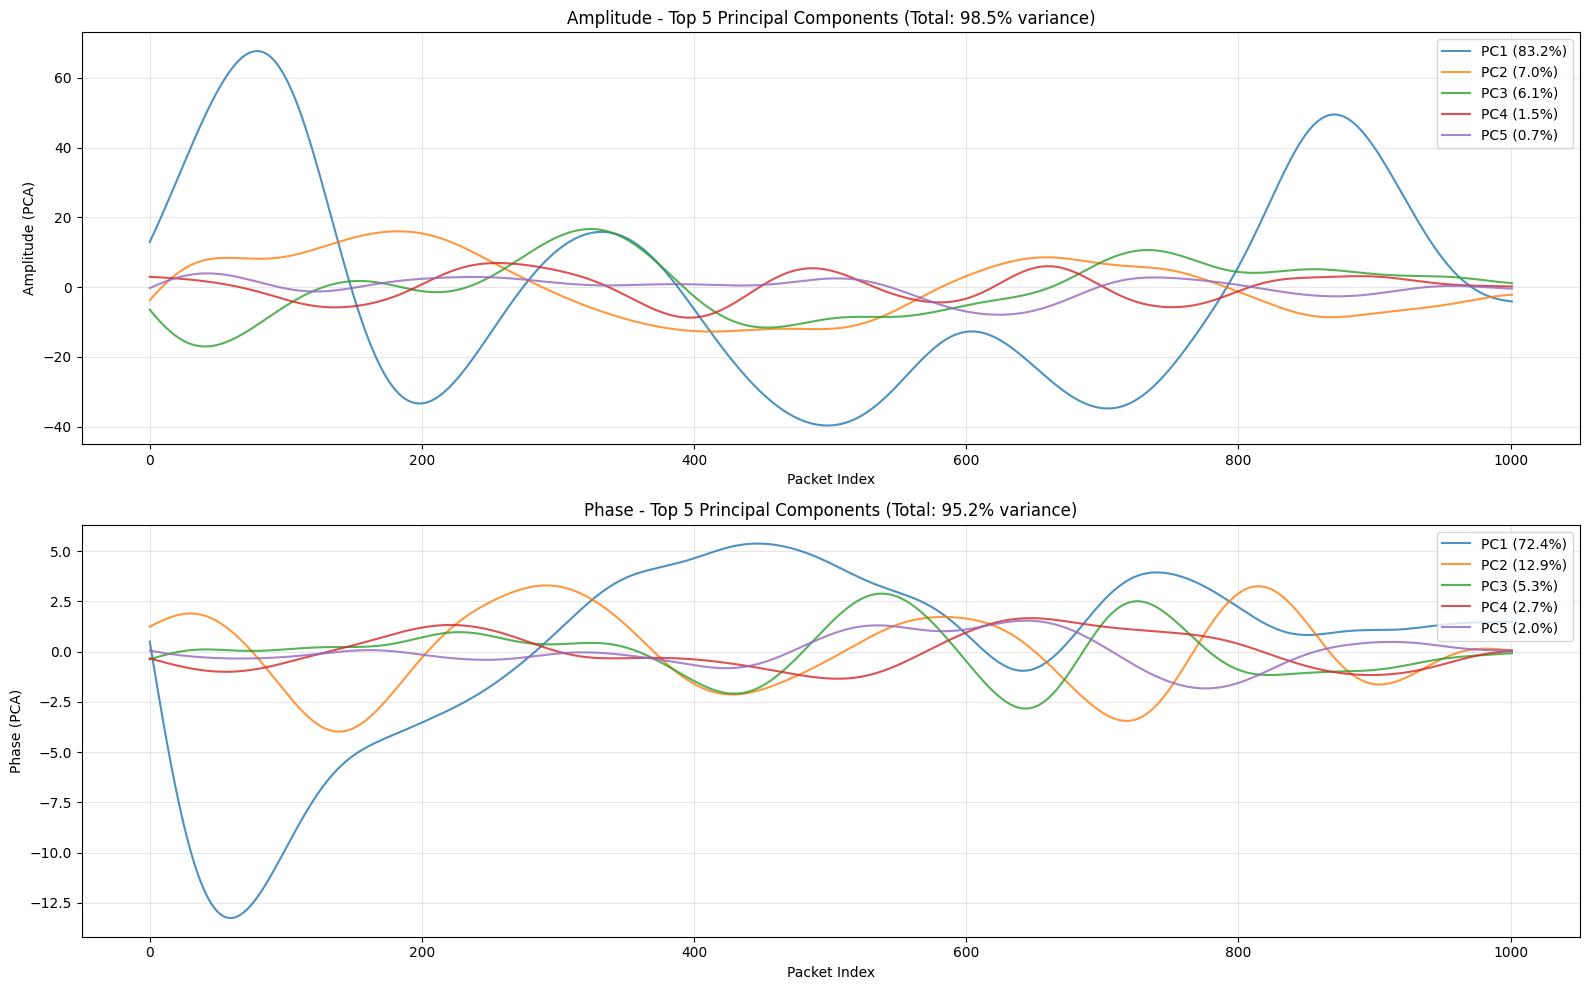


Principal Components Ready:
  amp_pca: shape (1002, 5) - 5 principal components from amplitude
  phs_pca: shape (1002, 5) - 5 principal components from phase


In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Vẽ 5 thành phần chính
packet_idx = np.arange(len(amp_pca))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot Amplitude - 5 principal components
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i in range(N_COMPONENTS):
    ax1.plot(packet_idx, amp_pca[:, i], linewidth=1.5, alpha=0.8, 
             color=colors[i], label=f'PC{i+1} ({pca_amp.explained_variance_ratio_[i]*100:.1f}%)')

ax1.set_xlabel('Packet Index')
ax1.set_ylabel('Amplitude (PCA)')
ax1.set_title(f'Amplitude - Top {N_COMPONENTS} Principal Components (Total: {np.sum(pca_amp.explained_variance_ratio_)*100:.1f}% variance)')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Plot Phase - 5 principal components
for i in range(N_COMPONENTS):
    ax2.plot(packet_idx, phs_pca[:, i], linewidth=1.5, alpha=0.8, 
             color=colors[i], label=f'PC{i+1} ({pca_phs.explained_variance_ratio_[i]*100:.1f}%)')

ax2.set_xlabel('Packet Index')
ax2.set_ylabel('Phase (PCA)')
ax2.set_title(f'Phase - Top {N_COMPONENTS} Principal Components (Total: {np.sum(pca_phs.explained_variance_ratio_)*100:.1f}% variance)')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nPrincipal Components Ready:")
print(f"  amp_pca: shape {amp_pca.shape} - {N_COMPONENTS} principal components from amplitude")
print(f"  phs_pca: shape {phs_pca.shape} - {N_COMPONENTS} principal components from phase")

# 9. Power Spectrogram (STFT) Feature Extraction for CNN

In [72]:
import numpy as np
from scipy.signal import spectrogram

# ============ Tham số Spectrogram ============
FS = 100.0          # Sampling frequency (Hz)
NPERSEG = 500       # Window length = 5s × 100 Hz
NOVERLAP = 450      # Overlap 90%
WINDOW = 'hann'     # Cửa sổ Hann

# Dải tần nhịp thở
BREATH_FREQ_MIN = 0.1   # Hz
BREATH_FREQ_MAX = 0.6   # Hz

print(f"Tính Power Spectrogram (STFT) cho {N_COMPONENTS} principal components...")
print(f"  Window: {WINDOW}, nperseg={NPERSEG} ({NPERSEG/FS:.1f}s)")
print(f"  Overlap: {NOVERLAP} ({NOVERLAP/NPERSEG*100:.0f}%)")
print(f"  Hop size: {NPERSEG - NOVERLAP} samples ({(NPERSEG - NOVERLAP)/FS:.2f}s)")
print(f"  Breathing band: [{BREATH_FREQ_MIN} - {BREATH_FREQ_MAX}] Hz\n")

def compute_spectrogram_matrix(pca_matrix, fs, nperseg, noverlap, window):
    """
    Tính spectrogram cho tất cả PCA components.
    Returns: freqs, times, list of Sxx matrices (one per component)
    """
    spectrograms = []
    freqs = None
    times = None
    
    for comp_idx in range(pca_matrix.shape[1]):
        f, t, Sxx = spectrogram(
            pca_matrix[:, comp_idx],
            fs=fs,
            window=window,
            nperseg=nperseg,
            noverlap=noverlap,
            scaling='density'   # Power Spectral Density (V²/Hz)
        )
        if freqs is None:
            freqs = f
            times = t
        spectrograms.append(Sxx)
    
    return freqs, times, spectrograms

def crop_freq_band(freqs, spectrograms, fmin, fmax):
    """Cắt dải tần quan tâm từ spectrogram."""
    mask = (freqs >= fmin) & (freqs <= fmax)
    cropped_freqs = freqs[mask]
    cropped_specs = [Sxx[mask, :] for Sxx in spectrograms]
    return cropped_freqs, cropped_specs

def to_decibel(spectrograms, ref=1e-12):
    """Chuyển Power Spectrogram sang dB: 10*log10(Sxx/ref)."""
    return [10 * np.log10(np.maximum(Sxx, ref) / ref) for Sxx in spectrograms]

# ============ Tính Spectrogram cho Amplitude PCA ============
spec_freqs, spec_times, spec_amp_full = compute_spectrogram_matrix(
    amp_pca, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP, window=WINDOW
)

# ============ Tính Spectrogram cho Phase PCA ============
_, _, spec_phs_full = compute_spectrogram_matrix(
    phs_pca, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP, window=WINDOW
)

print(f"Full Spectrogram:")
print(f"  Frequency bins: {len(spec_freqs)} ({spec_freqs[0]:.3f} - {spec_freqs[-1]:.3f} Hz)")
print(f"  Freq resolution: {spec_freqs[1] - spec_freqs[0]:.4f} Hz")
print(f"  Time frames: {len(spec_times)} ({spec_times[0]:.2f} - {spec_times[-1]:.2f} s)")
print(f"  Each component shape: {spec_amp_full[0].shape} (freq_bins × time_frames)")

# ============ Cắt dải tần nhịp thở ============
breath_freqs, breath_spec_amp = crop_freq_band(spec_freqs, spec_amp_full, BREATH_FREQ_MIN, BREATH_FREQ_MAX)
_, breath_spec_phs = crop_freq_band(spec_freqs, spec_phs_full, BREATH_FREQ_MIN, BREATH_FREQ_MAX)

print(f"\nBreathing Band [{BREATH_FREQ_MIN}-{BREATH_FREQ_MAX} Hz]:")
print(f"  Frequency bins: {len(breath_freqs)}")
print(f"  Each component shape: {breath_spec_amp[0].shape}")

# ============ Chuyển sang Decibel ============
breath_spec_amp_dB = to_decibel(breath_spec_amp)
breath_spec_phs_dB = to_decibel(breath_spec_phs)

print(f"\nDecibel range (Amplitude PC1):")
print(f"  Min: {np.min(breath_spec_amp_dB[0]):.1f} dB")
print(f"  Max: {np.max(breath_spec_amp_dB[0]):.1f} dB")

# ============ Stack thành tensor CNN-ready ============
# Shape: (N_COMPONENTS, n_freq_bins, n_time_frames) — giống multi-channel image
cnn_input_amp = np.stack(breath_spec_amp_dB, axis=0)   # (5, freq, time)
cnn_input_phs = np.stack(breath_spec_phs_dB, axis=0)   # (5, freq, time)

# Hoặc concat cả amp + phase: (10, freq, time)
cnn_input_combined = np.concatenate([cnn_input_amp, cnn_input_phs], axis=0)

print(f"\n{'='*60}")
print(f"CNN Input Tensors:")
print(f"  Amplitude only:  {cnn_input_amp.shape}  (channels=PC, freq, time)")
print(f"  Phase only:      {cnn_input_phs.shape}  (channels=PC, freq, time)")
print(f"  Combined:        {cnn_input_combined.shape}  (channels=amp+phs, freq, time)")
print(f"{'='*60}")

# Lưu feature matrices
feature_matrices = {
    'breath_freqs': breath_freqs,
    'spec_times': spec_times,
    'breath_spec_amp': breath_spec_amp,
    'breath_spec_phs': breath_spec_phs,
    'breath_spec_amp_dB': breath_spec_amp_dB,
    'breath_spec_phs_dB': breath_spec_phs_dB,
    'cnn_input_amp': cnn_input_amp,
    'cnn_input_phs': cnn_input_phs,
    'cnn_input_combined': cnn_input_combined,
}

print("\nFeature matrices saved!")

Tính Power Spectrogram (STFT) cho 5 principal components...
  Window: hann, nperseg=500 (5.0s)
  Overlap: 450 (90%)
  Hop size: 50 samples (0.50s)
  Breathing band: [0.1 - 0.6] Hz

Full Spectrogram:
  Frequency bins: 251 (0.000 - 50.000 Hz)
  Freq resolution: 0.2000 Hz
  Time frames: 11 (2.50 - 7.50 s)
  Each component shape: (251, 11) (freq_bins × time_frames)

Breathing Band [0.1-0.6 Hz]:
  Frequency bins: 2
  Each component shape: (2, 11)

Decibel range (Amplitude PC1):
  Min: 140.2 dB
  Max: 153.1 dB

CNN Input Tensors:
  Amplitude only:  (5, 2, 11)  (channels=PC, freq, time)
  Phase only:      (5, 2, 11)  (channels=PC, freq, time)
  Combined:        (10, 2, 11)  (channels=amp+phs, freq, time)

Feature matrices saved!


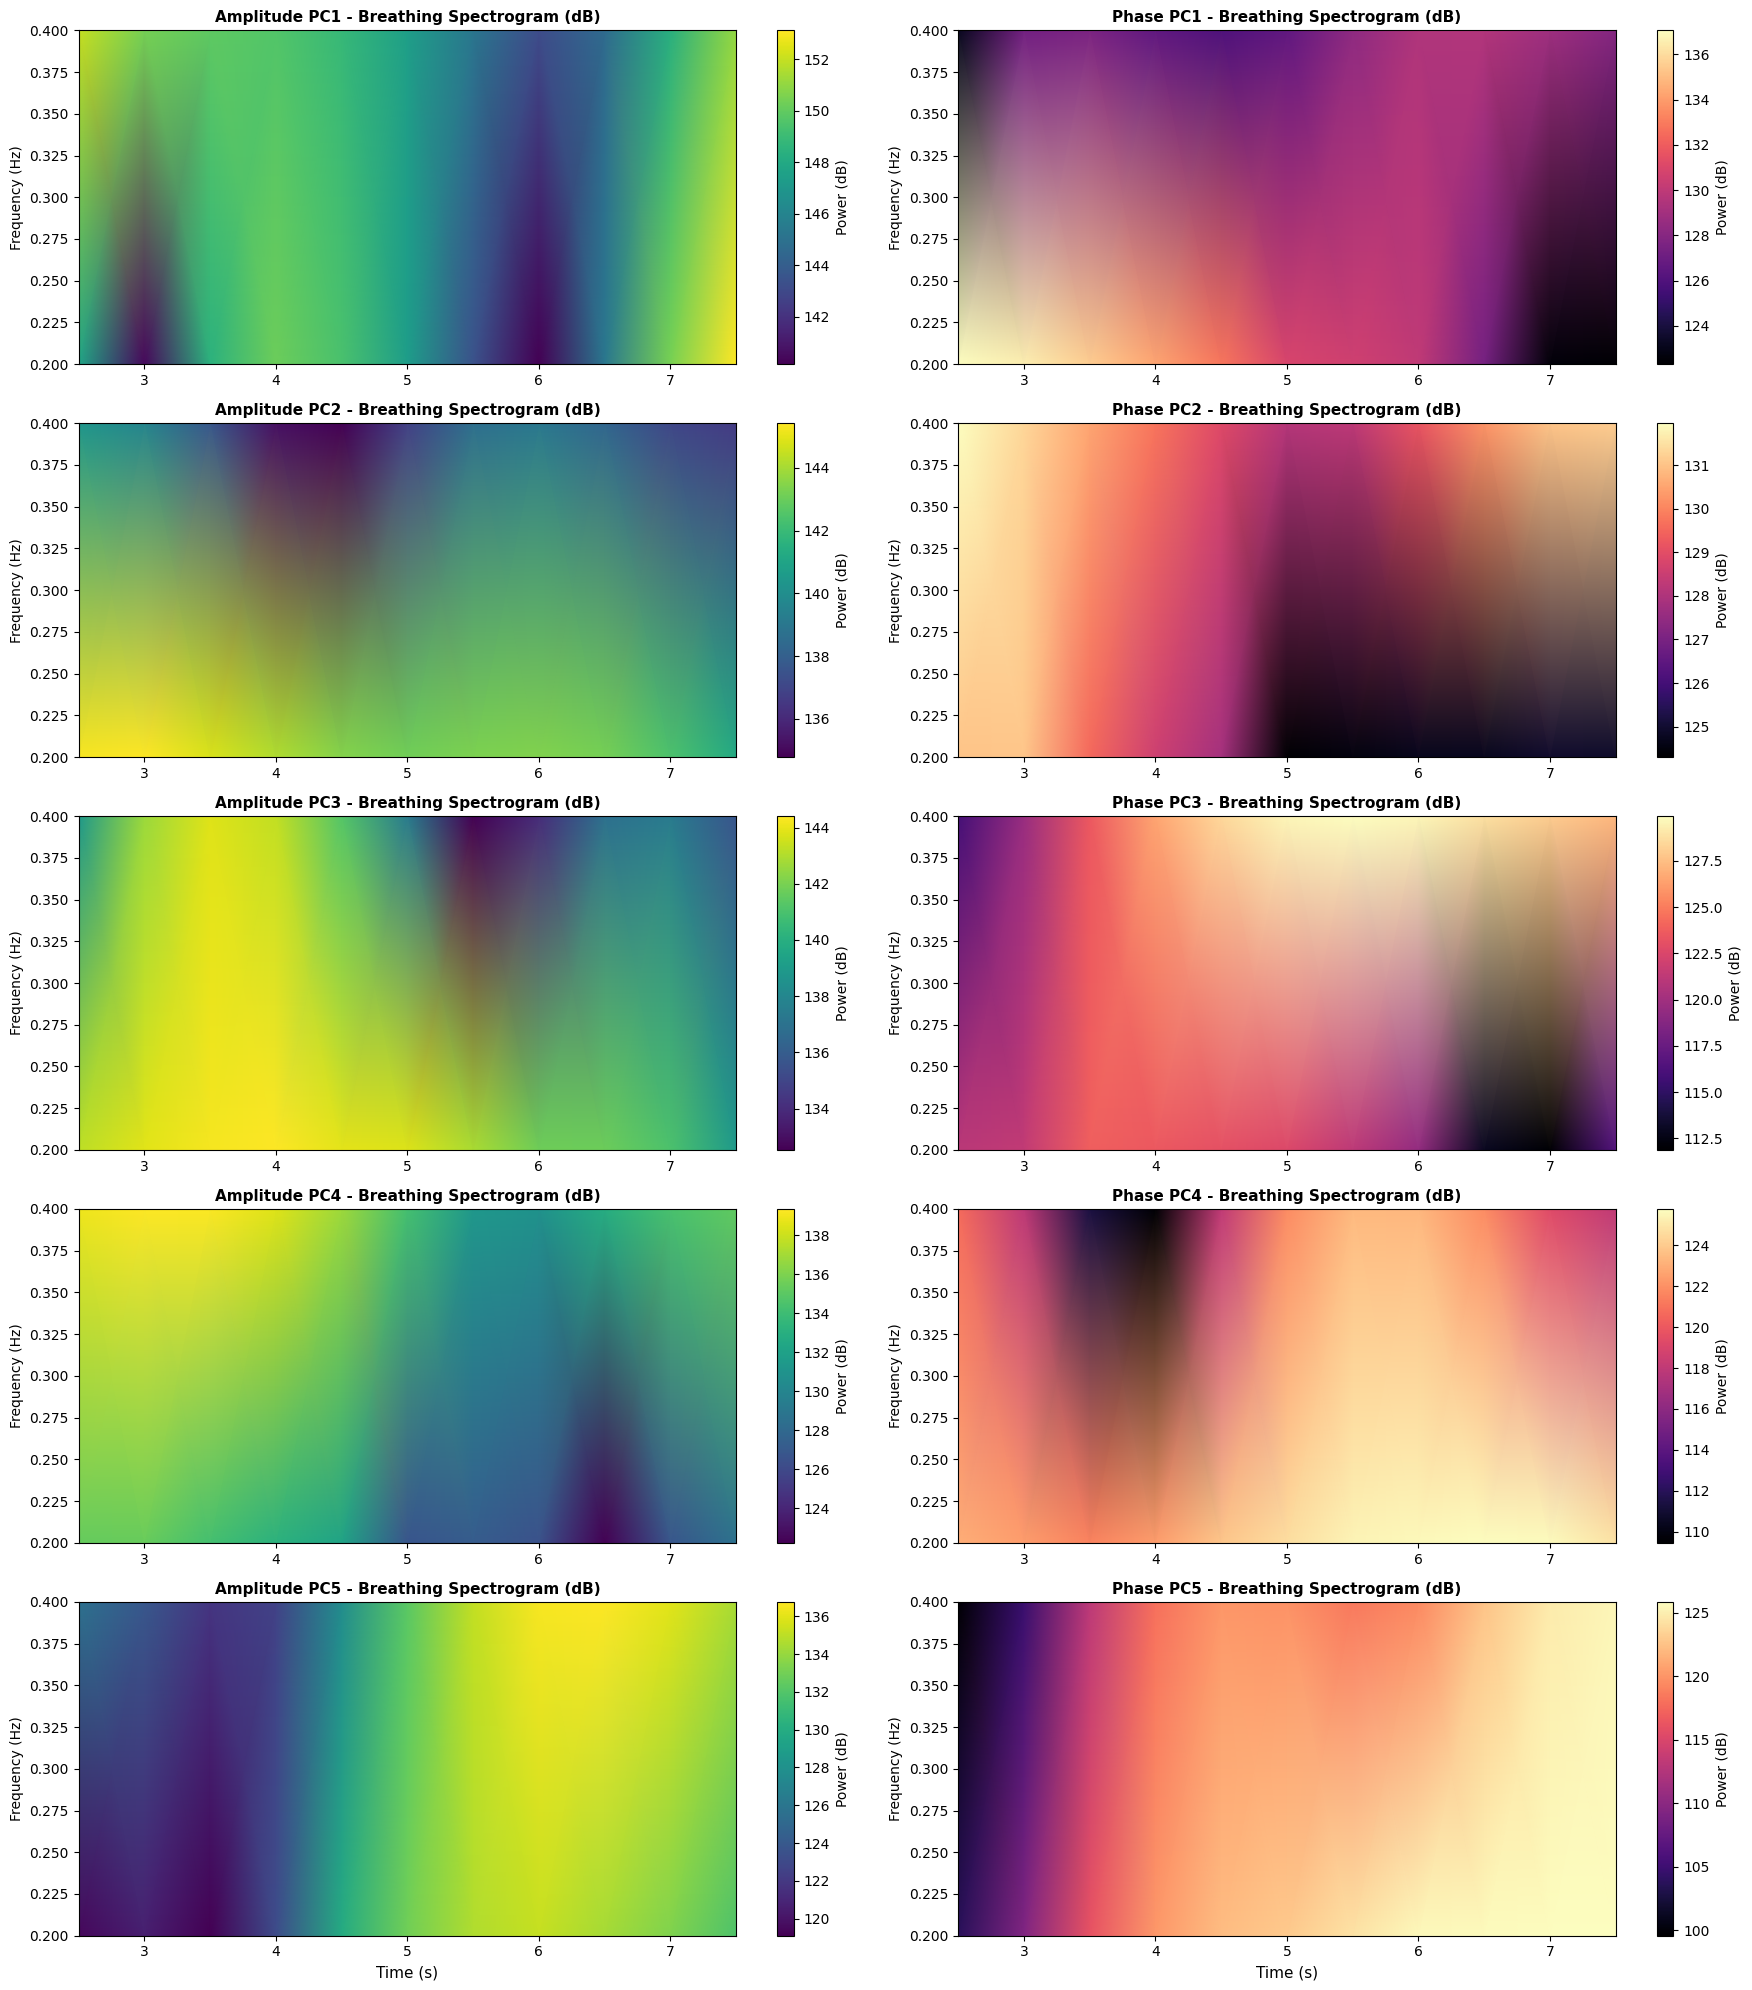

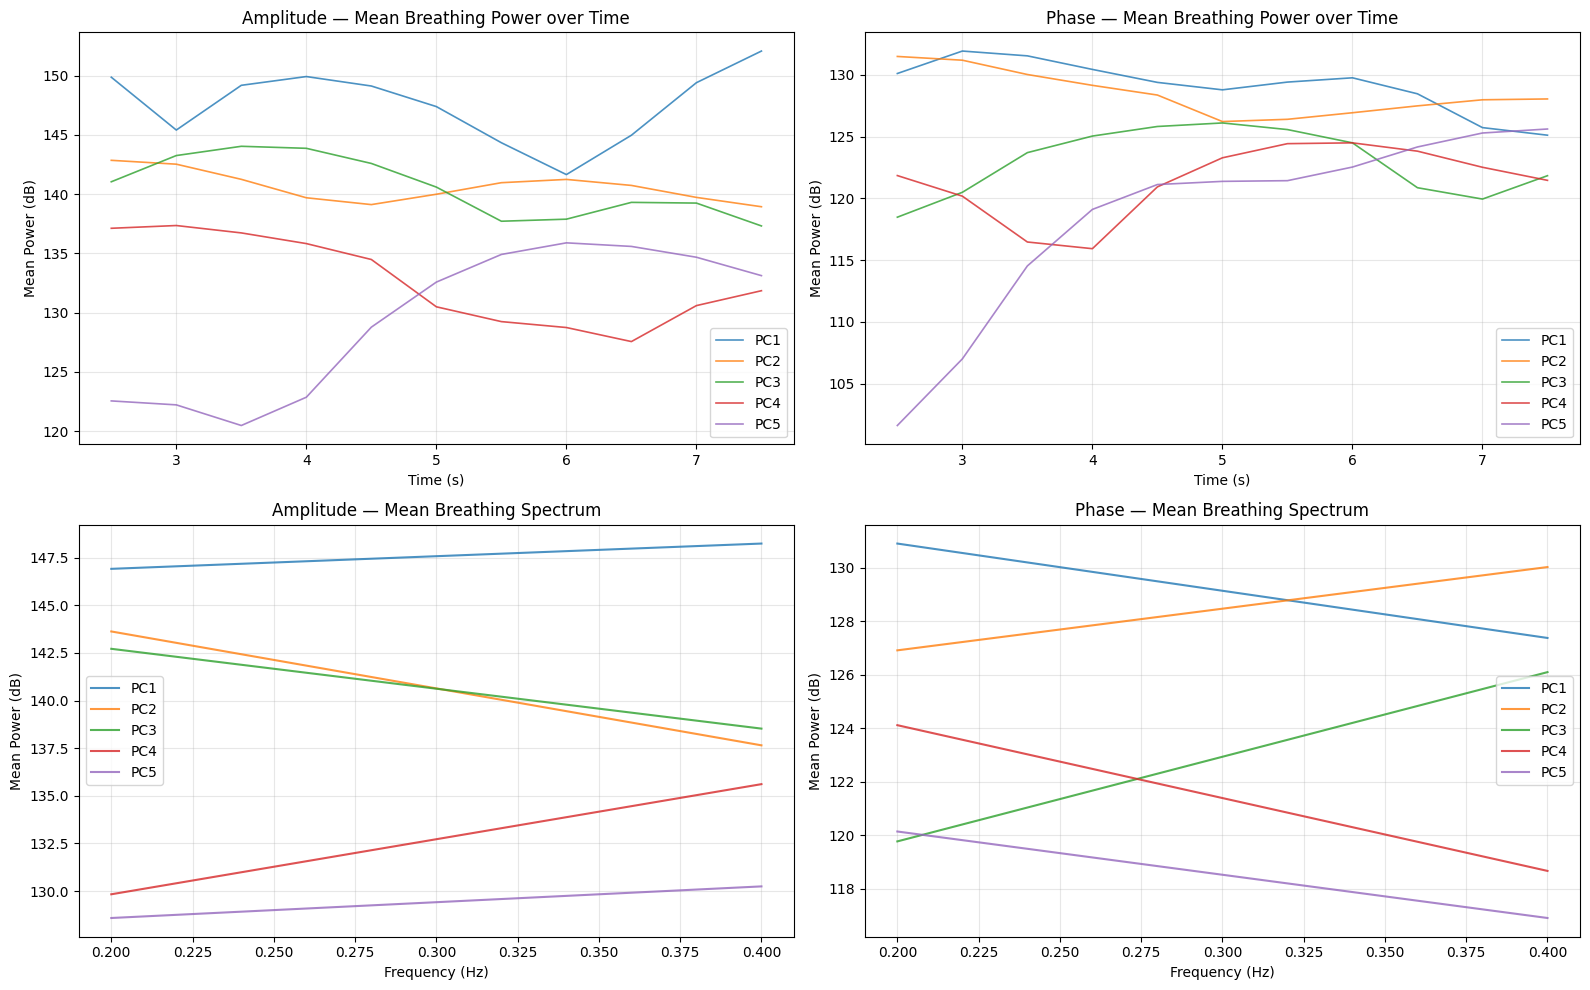

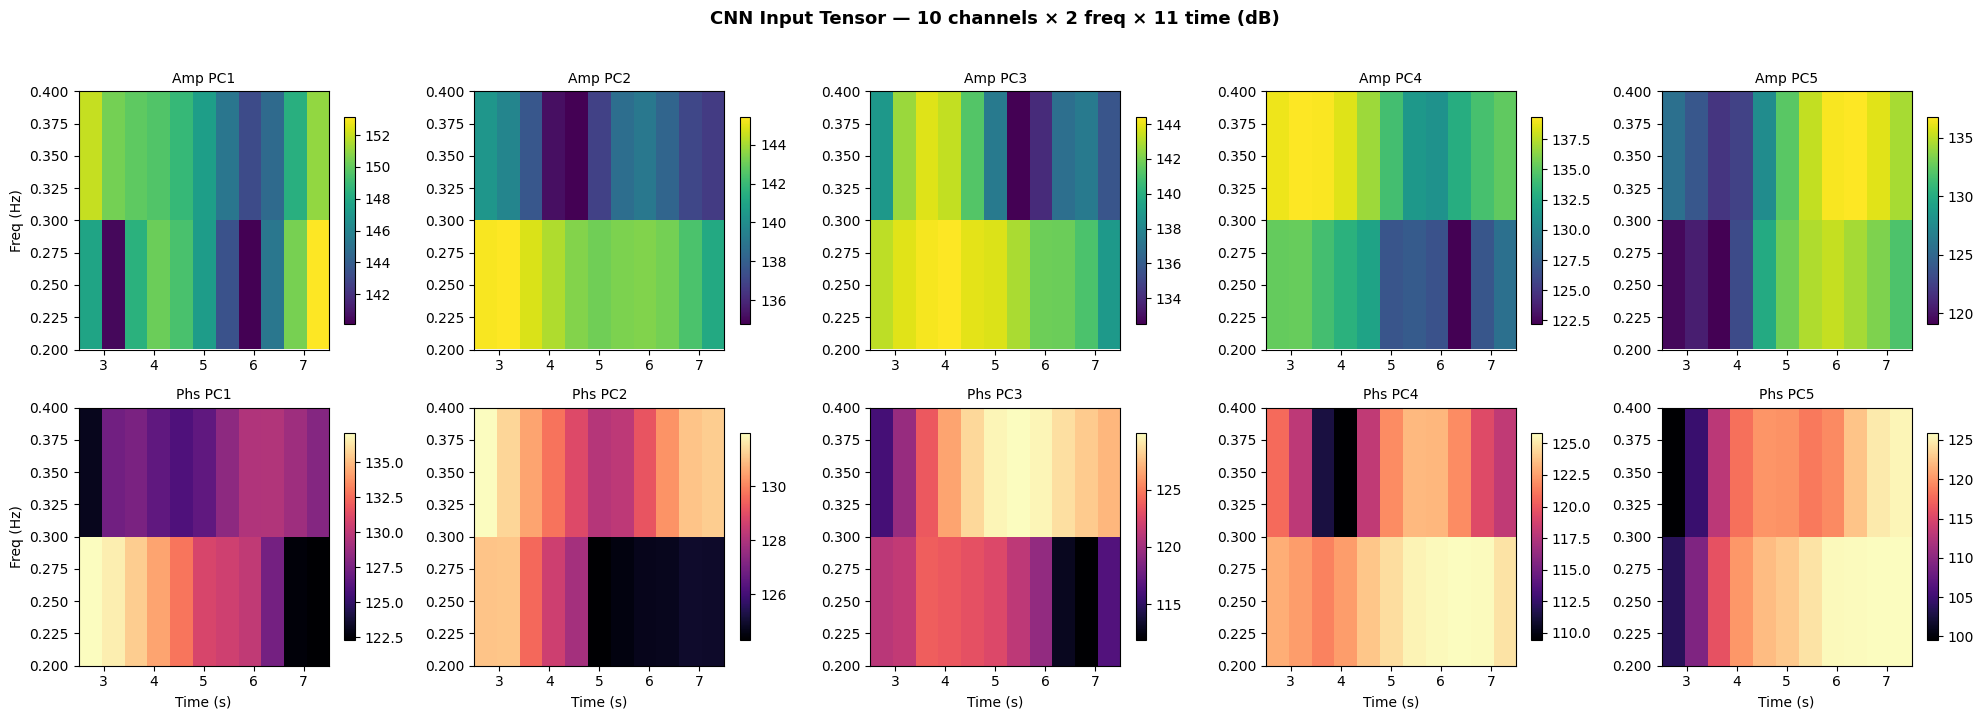


SPECTROGRAM STATISTICS (Breathing Band, dB)

PC1:
  Amplitude dB — min: 140.2, max: 153.1, mean: 147.6
  Phase dB    — min: 122.3, max: 137.1, mean: 129.1

PC2:
  Amplitude dB — min: 134.8, max: 145.4, mean: 140.6
  Phase dB    — min: 124.3, max: 132.0, mean: 128.5

PC3:
  Amplitude dB — min: 132.5, max: 144.4, mean: 140.6
  Phase dB    — min: 111.9, max: 129.9, mean: 122.9

PC4:
  Amplitude dB — min: 122.2, max: 139.3, mean: 132.7
  Phase dB    — min: 109.5, max: 125.8, mean: 121.4

PC5:
  Amplitude dB — min: 119.1, max: 136.8, mean: 129.4
  Phase dB    — min: 99.6, max: 125.8, mean: 118.5

Spectrogram params: window=hann 5s, overlap=90%, hop=50 samples
CNN tensor shape: (10, 2, 11)


In [73]:
import matplotlib.pyplot as plt
import numpy as np

colors_pc = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']

# ============================================================
# PLOT 1: Spectrogram heatmap cho từng PC (Amplitude, dB)
# ============================================================
fig, axes = plt.subplots(N_COMPONENTS, 2, figsize=(18, 4 * N_COMPONENTS))

for i in range(N_COMPONENTS):
    # --- Amplitude Spectrogram (dB) ---
    im_amp = axes[i, 0].pcolormesh(
        spec_times, breath_freqs, breath_spec_amp_dB[i],
        shading='gouraud', cmap='viridis'
    )
    axes[i, 0].set_ylabel('Frequency (Hz)', fontsize=10)
    axes[i, 0].set_title(f'Amplitude PC{i+1} - Breathing Spectrogram (dB)', fontsize=11, fontweight='bold')
    axes[i, 0].grid(False)
    fig.colorbar(im_amp, ax=axes[i, 0], label='Power (dB)')

    # --- Phase Spectrogram (dB) ---
    im_phs = axes[i, 1].pcolormesh(
        spec_times, breath_freqs, breath_spec_phs_dB[i],
        shading='gouraud', cmap='magma'
    )
    axes[i, 1].set_ylabel('Frequency (Hz)', fontsize=10)
    axes[i, 1].set_title(f'Phase PC{i+1} - Breathing Spectrogram (dB)', fontsize=11, fontweight='bold')
    axes[i, 1].grid(False)
    fig.colorbar(im_phs, ax=axes[i, 1], label='Power (dB)')

# Xlabel chỉ cho hàng cuối
axes[-1, 0].set_xlabel('Time (s)', fontsize=11)
axes[-1, 1].set_xlabel('Time (s)', fontsize=11)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Tổng hợp — Mean Power theo thời gian & tần số
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Mean power theo thời gian (trung bình trên freq axis) ---
for i in range(N_COMPONENTS):
    mean_power_t = np.mean(breath_spec_amp_dB[i], axis=0)  # mean over freq
    axes[0, 0].plot(spec_times, mean_power_t, linewidth=1.2, alpha=0.8,
                    color=colors_pc[i], label=f'PC{i+1}')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Mean Power (dB)')
axes[0, 0].set_title('Amplitude — Mean Breathing Power over Time')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

for i in range(N_COMPONENTS):
    mean_power_t = np.mean(breath_spec_phs_dB[i], axis=0)
    axes[0, 1].plot(spec_times, mean_power_t, linewidth=1.2, alpha=0.8,
                    color=colors_pc[i], label=f'PC{i+1}')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Mean Power (dB)')
axes[0, 1].set_title('Phase — Mean Breathing Power over Time')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# --- Mean power theo tần số (trung bình trên time axis) ---
for i in range(N_COMPONENTS):
    mean_power_f = np.mean(breath_spec_amp_dB[i], axis=1)  # mean over time
    axes[1, 0].plot(breath_freqs, mean_power_f, linewidth=1.5, alpha=0.8,
                    color=colors_pc[i], label=f'PC{i+1}')
axes[1, 0].set_xlabel('Frequency (Hz)')
axes[1, 0].set_ylabel('Mean Power (dB)')
axes[1, 0].set_title('Amplitude — Mean Breathing Spectrum')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

for i in range(N_COMPONENTS):
    mean_power_f = np.mean(breath_spec_phs_dB[i], axis=1)
    axes[1, 1].plot(breath_freqs, mean_power_f, linewidth=1.5, alpha=0.8,
                    color=colors_pc[i], label=f'PC{i+1}')
axes[1, 1].set_xlabel('Frequency (Hz)')
axes[1, 1].set_ylabel('Mean Power (dB)')
axes[1, 1].set_title('Phase — Mean Breathing Spectrum')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: CNN Input Tensor preview (combined channels)
# ============================================================
fig, axes = plt.subplots(2, N_COMPONENTS, figsize=(4 * N_COMPONENTS, 7))

for i in range(N_COMPONENTS):
    # Amplitude channel
    im = axes[0, i].imshow(
        cnn_input_combined[i], aspect='auto', origin='lower',
        extent=[spec_times[0], spec_times[-1], breath_freqs[0], breath_freqs[-1]],
        cmap='viridis'
    )
    axes[0, i].set_title(f'Amp PC{i+1}', fontsize=10)
    if i == 0:
        axes[0, i].set_ylabel('Freq (Hz)')
    fig.colorbar(im, ax=axes[0, i], shrink=0.8)

    # Phase channel
    im = axes[1, i].imshow(
        cnn_input_combined[N_COMPONENTS + i], aspect='auto', origin='lower',
        extent=[spec_times[0], spec_times[-1], breath_freqs[0], breath_freqs[-1]],
        cmap='magma'
    )
    axes[1, i].set_title(f'Phs PC{i+1}', fontsize=10)
    axes[1, i].set_xlabel('Time (s)')
    if i == 0:
        axes[1, i].set_ylabel('Freq (Hz)')
    fig.colorbar(im, ax=axes[1, i], shrink=0.8)

plt.suptitle(f'CNN Input Tensor — {cnn_input_combined.shape[0]} channels × '
             f'{cnn_input_combined.shape[1]} freq × {cnn_input_combined.shape[2]} time (dB)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Thống kê
# ============================================================
print(f"\n{'='*60}")
print("SPECTROGRAM STATISTICS (Breathing Band, dB)")
print(f"{'='*60}")
for i in range(N_COMPONENTS):
    print(f"\nPC{i+1}:")
    print(f"  Amplitude dB — min: {np.min(breath_spec_amp_dB[i]):.1f}, "
          f"max: {np.max(breath_spec_amp_dB[i]):.1f}, "
          f"mean: {np.mean(breath_spec_amp_dB[i]):.1f}")
    print(f"  Phase dB    — min: {np.min(breath_spec_phs_dB[i]):.1f}, "
          f"max: {np.max(breath_spec_phs_dB[i]):.1f}, "
          f"mean: {np.mean(breath_spec_phs_dB[i]):.1f}")

print(f"\n{'='*60}")
print(f"Spectrogram params: window={WINDOW} {NPERSEG/FS:.0f}s, "
      f"overlap={NOVERLAP/NPERSEG*100:.0f}%, hop={NPERSEG-NOVERLAP} samples")
print(f"CNN tensor shape: {cnn_input_combined.shape}")
print(f"{'='*60}")